# 03 Sentiment et audiences

Comment les 44 599 réponses qualifient-elles chaque candidat ? NSI, répartition hostilité/soutien, corrélation avec l'engagement.

## 3.1 Configuration

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)

_root = Path.cwd() if (Path.cwd() / "src").is_dir() else Path.cwd().parent
sys.path.insert(0, str(_root))
from src.utils import (
    COLORS, DATA_RAW, A1_DATA, A3_OUT, FIG_DIR,
    swiss_style, setup_mpl, load_replies, _safe_read
)
setup_mpl()
FIG_DIR.mkdir(parents=True, exist_ok=True)

replies = load_replies()
nsi = _safe_read(A3_OUT / "A3_nsi_by_candidate.csv")
weekly_tw = _safe_read(A1_DATA / "weekly_metrics_twitter.csv")
inflection = _safe_read(A3_OUT / "A3_inflection_points.csv")
sent_anomalies = _safe_read(A3_OUT / "A3_sentiment_vs_anomalies.csv")

## 3.2 NSI par candidat

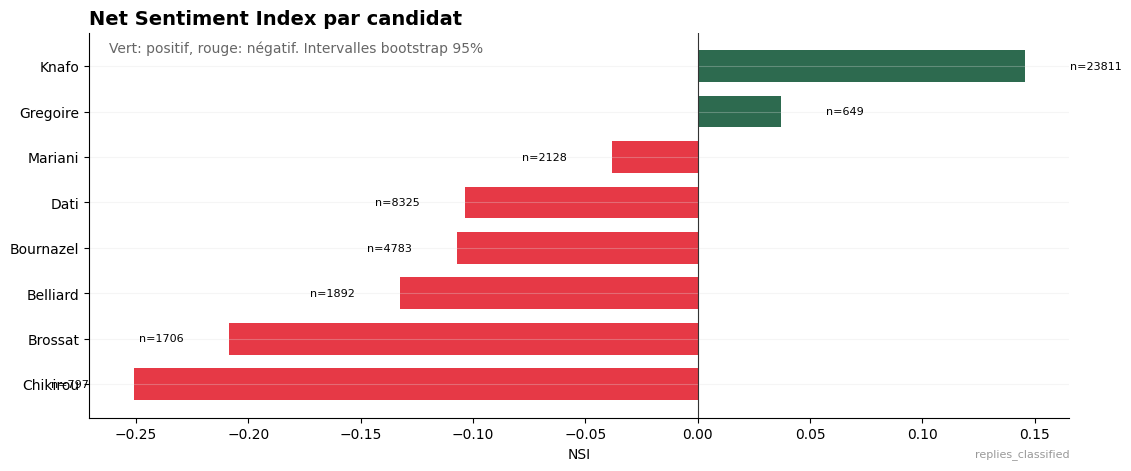

In [7]:
if nsi is not None:
    nsi_sorted = nsi.sort_values("nsi", ascending=True)
    fig, ax = plt.subplots(figsize=(14, 5))
    plt.subplots_adjust(left=0.2)
    colors = ["#2D6A4F" if v >= 0 else "#E63946" for v in nsi_sorted["nsi"]]
    bars = ax.barh(nsi_sorted["key"], nsi_sorted["nsi"], color=colors, height=0.7)
    ax.axvline(0, color="#333", lw=0.8)
    for i, (_, r) in enumerate(nsi_sorted.iterrows()):
        ax.text(r["nsi"] + (0.02 if r["nsi"] >= 0 else -0.02), i, f"n={int(r['n'])}", fontsize=8, va="center", ha="left" if r["nsi"] >= 0 else "right")
    swiss_style(ax, "Net Sentiment Index par candidat", "Vert: positif, rouge: négatif. Intervalles bootstrap 95%", "replies_classified")
    ax.set_xlabel("NSI")
    fig.savefig(FIG_DIR / "03_nsi_candidat.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

## 3.3 Distribution du sentiment

In [8]:
dist = replies["sentiment"].value_counts(normalize=True) * 100
fig, ax = plt.subplots(figsize=(8, 4))
cols_sent = {"CRITIQUE": "#F4A261", "SOUTIEN": "#2D6A4F", "HOSTILITÉ": "#E63946", "HOSTILITE": "#E63946", "IRONIE": "#6D4C41"}
for s in dist.index:
    ax.bar(str(s), dist[s], color=cols_sent.get(str(s), "#888"))
swiss_style(ax, "Distribution des 4 classes de sentiment", "Corpus 44 599 replies", "replies_classified")
ax.set_ylabel("%")
fig.savefig(FIG_DIR / "03_sentiment_dist.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# 3.3 Stacked barplot : proportion des 4 classes par candidat
sent_norm = replies["sentiment"].replace({"HOSTILITE": "HOSTILITÉ"})
prop = pd.crosstab(replies["candidate"], sent_norm, normalize="index") * 100
ord_sent = ["SOUTIEN", "CRITIQUE", "HOSTILITÉ", "IRONIE"]
prop = prop.reindex(columns=[c for c in ord_sent if c in prop.columns], fill_value=0)
prop = prop.loc[prop.sum(axis=1).sort_values(ascending=True).index]
fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(prop))
for col in prop.columns:
    ax.barh(prop.index, prop[col], left=bottom, label=col, color=cols_sent.get(col, "#888"), height=0.6)
    bottom += prop[col].values
ax.legend(loc="upper right", fontsize=9)
ax.set_xlabel("%")
swiss_style(ax, "3.3 Proportion des 4 classes par candidat", source="replies_classified")
fig.savefig(FIG_DIR / "03_stacked_sentiment_candidat.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 3.4 Évolution temporelle du NSI

Small multiples : NSI par semaine pour 4-5 candidats. Identification des bascules (inflection points) où le sentiment change de signe ou d'amplitude.

In [9]:
# NSI par semaine (soutien - hostilité) pour 4-5 candidats
sent_norm = replies["sentiment"].replace({"HOSTILITE": "HOSTILITÉ"})
rep_ym = replies.copy()
rep_ym["sent_norm"] = sent_norm
if "year_week" in rep_ym.columns and rep_ym["year_week"].notna().any():
    by_w = rep_ym.groupby(["candidate", "year_week"]).apply(
        lambda g: (g["sent_norm"] == "SOUTIEN").mean() - (g["sent_norm"] == "HOSTILITÉ").mean()
    ).reset_index(name="nsi")
    top_cands = ["Knafo", "Brossat", "Chikirou", "Dati", "Grégoire"]
    top_cands = [c for c in top_cands if c in by_w["candidate"].values or (c == "Grégoire" and "Gregoire" in by_w["candidate"].values)]
    by_w["cand_plot"] = by_w["candidate"].replace("Gregoire", "Grégoire")
    sub = by_w[by_w["cand_plot"].isin(top_cands)]
    n_plots = min(5, len(top_cands))
    fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4), sharey=True)
    axes = axes if n_plots > 1 else [axes]
    for i, c in enumerate(top_cands[:n_plots]):
        d = sub[sub["cand_plot"] == c].sort_values("year_week")
        axes[i].plot(range(len(d)), d["nsi"], color=COLORS.get(c, "#333"), lw=2)
        axes[i].axhline(0, color="#999", lw=0.8, ls="--")
        axes[i].set_xticks(range(0, len(d), max(1, len(d) // 6)))
        axes[i].set_xticklabels(d["year_week"].iloc[::max(1, len(d) // 6)], rotation=45, ha="right")
        axes[i].set_title(c, fontsize=11)
        swiss_style(axes[i], "", None, None)
    fig.suptitle("3.4 NSI par semaine (small multiples)", fontsize=14, fontweight="bold", x=0, y=1.02, ha="left")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "03_nsi_evolution.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

## 3.5 Négativité × engagement

Scatter % hostilité (semaine × candidat) × ER Twitter. Corrélation de Spearman. Annotation : Belliard ρ=+0.51 (négativité attire ER), Brossat ρ=-0.63.

In [10]:
# % hostilité par semaine x candidat vs ER Twitter
from scipy.stats import spearmanr
if "year_week" in replies.columns and weekly_tw is not None and len(weekly_tw) > 0:
    pct_host = rep_ym.groupby(["candidate", "year_week"]).apply(
        lambda g: (g["sent_norm"].isin(["HOSTILITÉ", "HOSTILITE"])).mean() * 100
    ).reset_index(name="pct_hostilite")
    pct_host["cand_norm"] = pct_host["candidate"].replace("Gregoire", "Grégoire")
    id_to_cand = {"david_belliard":"Belliard","ian_brossat":"Brossat","sophia_chikirou":"Chikirou","emmanuel_gregoire":"Grégoire","pierre_yves_bournazel":"Bournazel","rachida_dati":"Dati","sarah_knafo":"Knafo","thierry_mariani":"Mariani"}
    er_weekly = weekly_tw.groupby(["candidate_id", "year_week"])["er_median"].mean().reset_index()
    er_weekly["candidate"] = er_weekly["candidate_id"].map(id_to_cand)
    merged = pct_host.merge(er_weekly, left_on=["cand_norm", "year_week"], right_on=["candidate", "year_week"], how="inner")
    merged["er_pct"] = merged["er_median"] * 1000
    fig, ax = plt.subplots(figsize=(8, 5))
    for c in merged["cand_norm"].unique():
        sub = merged[merged["cand_norm"] == c]
        if len(sub) >= 3:
            r, p = spearmanr(sub["pct_hostilite"], sub["er_pct"])
            ax.scatter(sub["pct_hostilite"], sub["er_pct"], label=f"{c} ρ={r:.2f}", alpha=0.7, s=40)
    ax.legend(fontsize=8)
    ax.set_xlabel("% hostilité (semaine × candidat)")
    ax.set_ylabel("ER Twitter (‰)")
    swiss_style(ax, "3.5 Négativité × engagement", source="replies, weekly_metrics")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "03_negativite_engagement.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

## 3.6 Contenu × réaction

Heatmap candidat × indicateurs de sentiment (% hostilité, % soutien, NSI). Les colonnes montrent comment chaque candidat est perçu.

In [11]:
# Heatmap candidat × % hostilité, % soutien, NSI
mat = replies.groupby("candidate").apply(
    lambda g: pd.Series({
        "% hostilité": (g["sentiment"].isin(["HOSTILITÉ", "HOSTILITE"])).mean() * 100,
        "% soutien": (g["sentiment"] == "SOUTIEN").mean() * 100,
        "% critique": (g["sentiment"] == "CRITIQUE").mean() * 100,
        "NSI": (g["sentiment"] == "SOUTIEN").mean() - (g["sentiment"].isin(["HOSTILITÉ", "HOSTILITE"])).mean()
    })
).T
mat.index = ["% hostilité", "% soutien", "% critique", "NSI"]
mat = mat.reindex(columns=mat.columns.sort_values())
fig, ax = plt.subplots(figsize=(10, 4))
mat_norm = (mat - mat.min().min()) / (mat.max().max() - mat.min().min() + 1e-9)
im = ax.imshow(mat_norm.values, aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=1)
ax.set_xticks(range(len(mat.columns)))
ax.set_xticklabels(mat.columns, rotation=45, ha="right")
ax.set_yticks(range(len(mat.index)))
ax.set_yticklabels(mat.index)
plt.colorbar(im, ax=ax)
swiss_style(ax, "3.6 Candidat × indicateurs sentiment", source="replies_classified")
fig.tight_layout()
fig.savefig(FIG_DIR / "03_heatmap_sentiment.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 3.7 Wordclouds candidat × sentiment

Grille 2×4 HOSTILITÉ (rouge), grille 2×4 SOUTIEN (vert). Mots les plus fréquents dans les replies hostiles vs bienveillantes par candidat.

In [12]:
# Wordclouds HOSTILITÉ et SOUTIEN par candidat
from wordcloud import WordCloud
import re
STOP_FR = set("le la les un une des du de ce cette ces mon ma mes et ou mais donc car si que qui pour par avec".split())
def clean(t):
    if pd.isna(t) or not t: return ""
    s = re.sub(r"[^a-zàâäéèêëïîôùûüç\\s]", " ", str(t).lower())
    return " ".join(w for w in s.split() if len(w) > 1 and w not in STOP_FR)
rep_txt = replies.copy()
rep_txt["text_clean"] = rep_txt["text"].apply(clean)
rep_txt["sent_norm"] = rep_txt["sentiment"].replace({"HOSTILITE":"HOSTILITÉ"})
for sent_name, color in [("HOSTILITÉ", "Reds"), ("SOUTIEN", "Greens")]:
    sub = rep_txt[rep_txt["sent_norm"] == sent_name]
    cands = sub["candidate"].unique()[:8]
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    axes = axes.flatten()
    for i, c in enumerate(cands):
        txt = " ".join(sub[sub["candidate"] == c]["text_clean"].dropna())
        if len(txt) < 10: txt = "aucun"
        wc = WordCloud(max_words=50, background_color="white", colormap=color).generate(txt)
        axes[i].imshow(wc, interpolation="bilinear")
        axes[i].set_title(c, fontsize=10)
        axes[i].axis("off")
    for j in range(len(cands), 8): axes[j].axis("off")
    fig.suptitle(f"3.7 Wordclouds {sent_name}", fontsize=14, fontweight="bold", x=0, y=1.02, ha="left")
    fig.tight_layout()
    fname = "hostilite" if "HOSTILIT" in sent_name else "soutien"
    fig.savefig(FIG_DIR / f"03_wc_{fname}.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

## 3.8 TF-IDF par classe de sentiment

Concaténer les replies par classe (SOUTIEN, CRITIQUE, HOSTILITÉ, IRONIE), appliquer TF-IDF sur 4 documents. Top 15 mots par classe. Montrer que CRITIQUE et HOSTILITÉ ont des signatures distinctes.

In [13]:
# TF-IDF sur 4 docs (une par classe)
from sklearn.feature_extraction.text import TfidfVectorizer
rep_txt["sent_cls"] = rep_txt["sentiment"].replace({"HOSTILITE":"HOSTILITÉ"})
docs_sent = rep_txt.groupby("sent_cls")["text_clean"].apply(lambda x: " ".join(x.dropna())).to_dict()
if len(docs_sent) >= 2:
    vec = TfidfVectorizer(max_features=3000, min_df=5)
    mat = vec.fit_transform(list(docs_sent.values()))
    names = vec.get_feature_names_out()
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.flatten()
    for i, (cls, txt) in enumerate(docs_sent.items()):
        if i >= 4: break
        row = mat[i].toarray().flatten()
        idx = np.argsort(row)[-15:][::-1]
        mots = [names[j] for j in idx if row[j] > 0]
        vals = [row[j] for j in idx if row[j] > 0]
        if mots:
            axes[i].barh(range(len(mots)), vals, color={"SOUTIEN":"#2D6A4F","CRITIQUE":"#F4A261","HOSTILITÉ":"#E63946","IRONIE":"#6D4C41"}.get(cls, "#888"))
            axes[i].set_yticks(range(len(mots)))
            axes[i].set_yticklabels(mots, fontsize=9)
        axes[i].set_title(cls, fontsize=11)
        swiss_style(axes[i], "", None, None)
    fig.suptitle("3.8 TF-IDF par classe de sentiment", fontsize=14, fontweight="bold", x=0, y=1.02, ha="left")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "03_tfidf_sentiment.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

## 3.9 Replies qui engagent

Top 10 replies par classe (likes). Tableau : texte, candidat, likes, plateforme.

In [14]:
# Top 10 replies par classe (likes)
replies["likes"] = pd.to_numeric(replies["likes"], errors="coerce").fillna(0)
for cls in ["SOUTIEN", "CRITIQUE", "HOSTILITÉ", "IRONIE"]:
    sub = replies[replies["sentiment"].isin([cls, "HOSTILITE"] if "HOSTILIT" in cls else [cls])]
    top = sub.nlargest(10, "likes")[["text", "candidate", "likes", "platform"]]
    top["text_short"] = top["text"].fillna("").apply(lambda s: (s[:80] + "...") if len(str(s)) > 80 else s)
    print(f"\\n--- Top 10 {cls} ---\\n", top[["text_short", "candidate", "likes", "platform"]].to_string())

\n--- Top 10 SOUTIEN ---\n                                                                                   text_short  candidate   likes platform
5109                                                      La plus soutenue par vos partisans      Knafo  135229  twitter
16500    Très belle copie, Sarah. 18/20, sans faute de syntaxe. Première de la promo, n’e...      Knafo   80698  twitter
39375    Diane Keaton’s candid reflection on her role in The Godfather reveals her tradem...  Bournazel   53291  twitter
16464                            La réponse est toujours ici : linkedin.com/pulse/nicolas-r…      Knafo   50961  twitter
5623     Et les Vénézuéliens dans le monde entier le démontrent avec leurs larmes de joie...      Knafo   46732  twitter
16089    Remplacer la dépense inutle par l'absence de dépense inutile. Vous avez bien com...      Knafo   41854  twitter
39368                      Legends don’t really die, they just stop taking calls from Earth.  Bournazel   41054  twitter
16795

## 3.10 Ironie

Barplot % ironie par candidat. Boxplot likes par classe (dont IRONIE). Exemples de replies ironiques.

In [15]:
# % ironie par candidat + boxplot likes par classe
pct_ironie = replies.groupby("candidate").apply(
    lambda g: (g["sentiment"] == "IRONIE").mean() * 100
).sort_values(ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].barh(pct_ironie.index, pct_ironie.values, color="#6D4C41", alpha=0.8)
swiss_style(axes[0], "3.10a % ironie par candidat", source="replies_classified")
replies["sent_cls"] = replies["sentiment"].replace({"HOSTILITE":"HOSTILITÉ"})
bp = axes[1].boxplot([replies[replies["sent_cls"]==c]["likes"].clip(upper=replies["likes"].quantile(0.95)) for c in ["SOUTIEN","CRITIQUE","HOSTILITÉ","IRONIE"]], labels=["SOUTIEN","CRITIQUE","HOSTILITÉ","IRONIE"], patch_artist=True)
for p in bp["boxes"]: p.set_facecolor("#f0f0f0")
swiss_style(axes[1], "3.10b Likes par classe", source="replies_classified")
fig.tight_layout()
fig.savefig(FIG_DIR / "03_ironie.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
# Exemples ironiques
ex = replies[replies["sentiment"]=="IRONIE"].nlargest(3, "likes")[["text","candidate","likes"]]
print("Exemples ironiques:", ex.to_string())

Exemples ironiques:                                                                                                                                           text  candidate  likes
5394                     Ptdr ça va jamais dans le métro que t es obligée de te filmer dedans quand tu fais ton expédition en terre inconnue 😭      Knafo  46004
39374                    Your Kay lives in all our heads. From Annie Hall to Marvin’s Room, she was truthful in every frame. Rest easy, Diane.  Bournazel  42993
16090  Après une démonstration aussi magistrale Juliette Méadel a annoncé son déménagement en Californie (dans le 93), dans la Silicone Voilée      Knafo  39621


## 3.11 Longueur × sentiment

Boxplot longueur (nombre de mots) par classe de sentiment. Les replies hostiles ou critiques sont-elles plus longues que les réponses de soutien ?

In [16]:
# Boxplot longueur (mots) par classe
replies["n_mots"] = replies["text"].fillna("").str.split().str.len()
fig, ax = plt.subplots(figsize=(8, 4))
order = ["SOUTIEN", "CRITIQUE", "HOSTILITÉ", "IRONIE"]
data = [replies[replies["sent_cls"]==c]["n_mots"].clip(upper=200) for c in order]
bp = ax.boxplot(data, labels=order, patch_artist=True)
for p in bp["boxes"]: p.set_facecolor("#f0f0f0")
ax.set_ylabel("Nombre de mots")
swiss_style(ax, "3.11 Longueur des replies par classe", source="replies_classified")
fig.tight_layout()
fig.savefig(FIG_DIR / "03_longueur_sentiment.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 3.4 Synthèse

Knafo (NSI +0,15) et Grégoire (+0,04) sont les seuls à bilan positif. Chikirou est la plus mal perçue (NSI -0,25, 39,6 % d'hostilité). Brossat (-0,21) et Belliard (-0,13) suivent. Le corpus global penche vers la critique (38 %) puis le soutien (27 %), l'hostilité (24 %) et l'ironie (11 %).